In [1]:
import os
from pathlib import Path

import dotenv
import matplotlib.pyplot as plt
import pyam

dotenv.load_dotenv()

# Set up output folder
OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

/Users/ganti/Documents/code/ar7_netzero_assessment/.venv/lib/python3.13/site-packages/jwt/api_jwt.py:147: InsecureKeyLengthWarning: The HMAC key is 20 bytes long, which is below the minimum recommended length of 32 bytes for SHA256. See RFC 7518 Section 3.2.
  return self._jws.encode(


## Configuration

In [2]:
# Scenario to plot
ILLUSTRATIVE_SCENARIO = ("IMAGE 3.0.1", "SSP1-19")

# File paths
INPUT_DATA_FILE = OUTPUT_FOLDER / "100_inputdata_20260428.csv"
HARMONISED_DATA_FILE = OUTPUT_FOLDER / "101_harmonised_data.csv"
NETZERO_CO2_FILE = OUTPUT_FOLDER / "102_netzero_co2_extended.csv"
NETZERO_KYOTO_FILE = OUTPUT_FOLDER / "102_netzero_kyoto_extended.csv"
HISTORY_DATA_FILE = Path(os.environ["HIST_DATA"])

# Year range for historical data
YEAR_RANGE = range(2000, 2101)

## Load Data

In [3]:
model, scenario = ILLUSTRATIVE_SCENARIO

# Input data (original scenario submissions)
input_data = pyam.IamDataFrame(INPUT_DATA_FILE).filter(model=model, scenario=scenario)

# Historical data
history = pyam.IamDataFrame(HISTORY_DATA_FILE)
history_data = pyam.IamDataFrame(
    history.timeseries().reset_index().assign(model="hist")
).filter(year=YEAR_RANGE)

# Harmonised and infilled data
harmonised_data = pyam.IamDataFrame(HARMONISED_DATA_FILE).filter(model=model, scenario=scenario)

# Net-zero extended scenarios
netzero_co2_data = pyam.IamDataFrame(NETZERO_CO2_FILE).filter(
    model=model, scenario=f"{scenario}_NZCO2"
)
netzero_kyoto_data = pyam.IamDataFrame(NETZERO_KYOTO_FILE).filter(
    model=model, scenario=f"{scenario}_NZKyoto"
)

[INFO] 12:20:47 - pyam.core: Reading file /Users/ganti/Documents/code/ar7_netzero_assessment/analysis/output/100_inputdata_20260428.csv
[INFO] 12:20:48 - pyam.core: Reading file /Users/ganti/Documents/data/cmip7-data/global-workflow-history_202511261223_202511040855_202512032146_202512021030_7e32405ade790677a6022ff498395bff00d9792d_202511040855_202512071232_202511040855_202511040855_0002_0002.csv
[INFO] 12:20:48 - pyam.core: Reading file /Users/ganti/Documents/code/ar7_netzero_assessment/analysis/output/101_harmonised_data.csv
[INFO] 12:20:50 - pyam.core: Reading file /Users/ganti/Documents/code/ar7_netzero_assessment/analysis/output/102_netzero_co2_extended.csv
[INFO] 12:20:51 - pyam.core: Reading file /Users/ganti/Documents/code/ar7_netzero_assessment/analysis/output/102_netzero_kyoto_extended.csv


## Process CO2 Emissions

In [4]:
# Input data uses different variable naming convention
input_co2 = input_data.add(
    a="Emissions|CO2|Energy and Industrial Processes",
    b="Emissions|CO2|AFOLU",
    name="Emissions|CO2",
)

history_co2 = history_data.add(
    a="Emissions|CO2|Energy and Industrial Processes",
    b="Emissions|CO2|AFOLU",
    name="Emissions|CO2",
)

# Harmonised data uses Fossil/Biosphere naming
harmonised_co2 = harmonised_data.add(
    a="Emissions|CO2|Fossil",
    b="Emissions|CO2|Biosphere",
    name="Emissions|CO2",
)

netzero_co2 = netzero_co2_data.add(
    a="Emissions|CO2|Fossil",
    b="Emissions|CO2|Biosphere",
    name="Emissions|CO2",
)

netzero_kyoto_co2 = netzero_kyoto_data.add(
    a="Emissions|CO2|Fossil",
    b="Emissions|CO2|Biosphere",
    name="Emissions|CO2",
)

## Process CH4 Emissions

In [5]:
CH4_VAR = "Emissions|CH4"

input_ch4 = input_data.filter(variable=CH4_VAR)
history_ch4 = history_data.filter(variable=CH4_VAR)
harmonised_ch4 = harmonised_data.filter(variable=CH4_VAR)
netzero_co2_ch4 = netzero_co2_data.filter(variable=CH4_VAR)
netzero_kyoto_ch4 = netzero_kyoto_data.filter(variable=CH4_VAR)

## Plot

Saved to /Users/ganti/Documents/code/ar7_netzero_assessment/analysis/output/900_illustrative_plot_IMAGE_301_SSP1_19.png


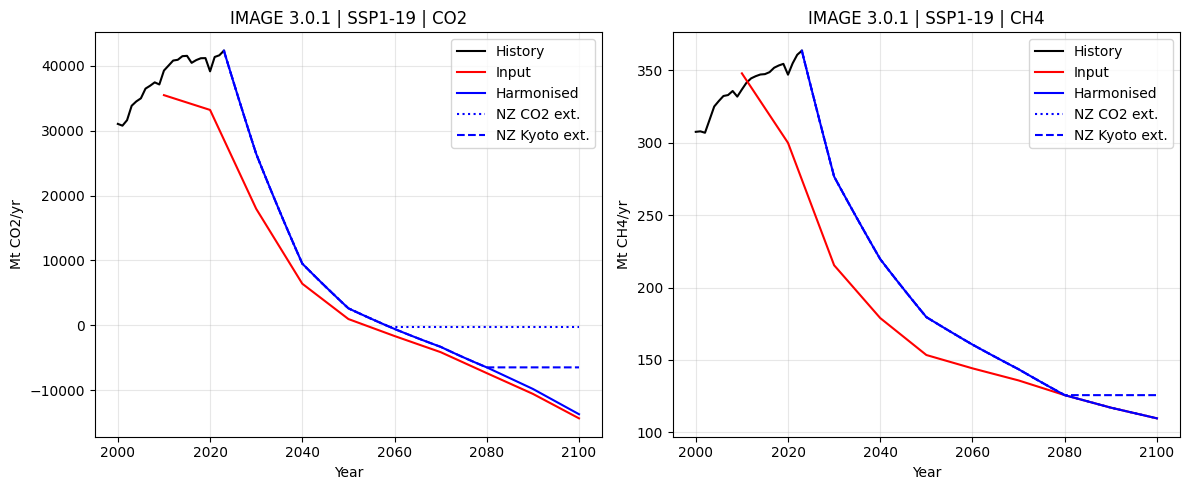

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CO2 plot
ax = axes[0]
history_co2.plot(ax=ax, color="black", label="History")
input_co2.plot(ax=ax, color="red", label="Input")
harmonised_co2.plot(ax=ax, color="blue", label="Harmonised")
netzero_co2.plot(ax=ax, color="blue", linestyle="dotted", label="NZ CO2 ext.")
netzero_kyoto_co2.plot(ax=ax, color="blue", linestyle="dashed", label="NZ Kyoto ext.")
ax.set_title(f"{model} | {scenario} | CO2")
ax.grid(alpha=0.3)

# CH4 plot
ax = axes[1]
history_ch4.plot(ax=ax, color="black", label="History")
input_ch4.plot(ax=ax, color="red", label="Input")
harmonised_ch4.plot(ax=ax, color="blue", label="Harmonised")
netzero_co2_ch4.plot(ax=ax, color="blue", linestyle="dotted", label="NZ CO2 ext.")
netzero_kyoto_ch4.plot(ax=ax, color="blue", linestyle="dashed", label="NZ Kyoto ext.")
ax.set_title(f"{model} | {scenario} | CH4")
ax.grid(alpha=0.3)

plt.tight_layout()

# Save figure
output_filename = OUTPUT_FOLDER / f"900_illustrative_plot_{model.replace(' ', '_').replace('.', '')}_{scenario.replace('-', '_')}.png"
fig.savefig(output_filename, dpi=150, bbox_inches="tight")
print(f"Saved to {output_filename}")